# **Day 14: Maximum Likelihood, MAP and Where Loss Functions Come From**
*Module 2 - Probability, Statistics and Optimisation*

Why does linear regression minimise **squared** error? Why does logistic regression use **cross-entropy**? Why does Ridge add $\lambda\lVert w\rVert^2$? All three answers come from one idea: **probabilistic modelling**.

> Maximum likelihood chooses the parameters that make the observed data most probable. Most loss functions come from this idea: squared error assumes Gaussian noise and log-loss assumes a Bernoulli outcome. MAP adds prior knowledge, which acts as regularisation.
>
> *Example:* If a coin gives 7 heads in 10 tosses, maximum likelihood estimates p = 0.7. A prior belief that coins are usually fair (MAP) pulls the estimate towards 0.5.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats, optimize
rng = np.random.default_rng(14)

## **1. Likelihood**
Given data $D=\{x_1,\dots,x_n\}$ and a model with parameter $\theta$, the **likelihood** is the probability of the observed data, viewed as a function of $\theta$:
$$\mathcal{L}(\theta) = \prod_{i=1}^n p(x_i\mid\theta),\qquad \ell(\theta)=\log\mathcal{L}(\theta)=\sum_i\log p(x_i\mid\theta)$$
**MLE**: choose $\hat\theta = \arg\max_\theta \ell(\theta)$. (Logs turn products into sums and avoid numerical underflow.)

### Example: coin flips (Bernoulli)
$\ell(p) = k\log p + (n-k)\log(1-p)$. Setting $d\ell/dp = 0$ gives $\hat p = k/n$.

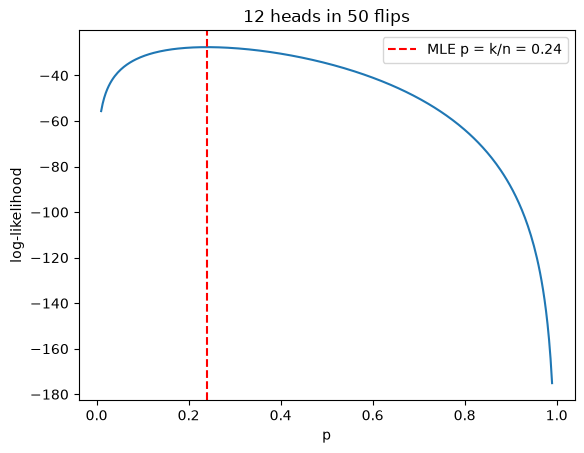

Product of 50 probabilities underflows quickly: 0.0 | log-sum: -2407.945608651872


In [2]:
flips = rng.random(50) < 0.3
k, n = flips.sum(), len(flips)
ps = np.linspace(0.01, 0.99, 300)
loglik = k * np.log(ps) + (n - k) * np.log(1 - ps)
plt.plot(ps, loglik); plt.axvline(k / n, c="r", ls="--", label=f"MLE p = k/n = {k / n:.2f}")
plt.xlabel("p"); plt.ylabel("log-likelihood"); plt.legend(); plt.title(f"{k} heads in {n} flips"); plt.show()
print("Product of 50 probabilities underflows quickly:", np.prod(np.full(2000, 0.3)), "| log-sum:", 2000 * np.log(0.3))

## **2. MLE for a Gaussian**
For $x_i \sim \mathcal{N}(\mu,\sigma^2)$, the MLE is $\hat\mu=\bar x$ and $\hat\sigma^2=\frac1n\sum(x_i-\bar x)^2$ (note: $1/n$, the biased version from Day 10). Let us confirm numerically by minimising the **negative log-likelihood (NLL)**.

In [3]:
data = rng.normal(5.0, 2.0, 200)
def nll(params):
    mu, log_sigma = params
    return -np.sum(stats.norm.logpdf(data, mu, np.exp(log_sigma)))   # optimise log(sigma) so sigma > 0
res = optimize.minimize(nll, x0=[0.0, 0.0])
print(f"Numerical MLE: mu = {res.x[0]:.4f}, sigma = {np.exp(res.x[1]):.4f}")
print(f"Closed form  : mu = {data.mean():.4f}, sigma = {data.std(ddof=0):.4f}")

Numerical MLE: mu = 5.0335, sigma = 1.8806
Closed form  : mu = 5.0335, sigma = 1.8806


## **3. Loss Functions Are Negative Log-Likelihoods**

**Regression with Gaussian noise:** $y_i = f(x_i) + \varepsilon_i$, $\varepsilon_i\sim\mathcal N(0,\sigma^2)$
$$-\ell = \frac{1}{2\sigma^2}\sum_i (y_i - f(x_i))^2 + \text{const} \;\;\Rightarrow\;\; \textbf{MLE} = \textbf{least squares (MSE)}$$

**Laplace noise** $p(\varepsilon)\propto e^{-|\varepsilon|/b}$ gives **MAE** (robust to outliers, predicts the median).

**Binary classification** $y\sim\text{Bernoulli}(\sigma(w^\top x))$ gives $-\ell = -\sum[y\log p + (1-y)\log(1-p)]$ = **cross-entropy**.

**Count data** $y\sim\text{Poisson}(e^{w^\top x})$ gives the **Poisson deviance** (Day 26).

Let us see why the noise assumption matters: data with a few outliers, fitted by Gaussian-MLE (MSE) and Laplace-MLE (MAE).

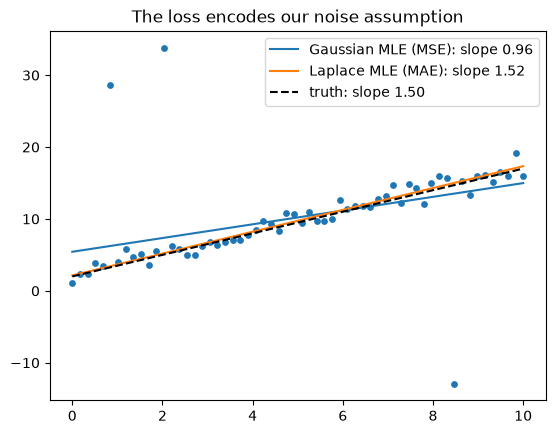

In [4]:
x = np.linspace(0, 10, 60)
y = 1.5 * x + 2 + rng.normal(0, 1, 60)
y[[5, 12, 50]] += [25, 30, -28]                                       # outliers

fit_mse = optimize.minimize(lambda w: np.sum((y - w[0] * x - w[1]) ** 2), [0, 0]).x
fit_mae = optimize.minimize(lambda w: np.sum(np.abs(y - w[0] * x - w[1])), [0, 0], method="Nelder-Mead").x
plt.scatter(x, y, s=15)
plt.plot(x, fit_mse[0] * x + fit_mse[1], label=f"Gaussian MLE (MSE): slope {fit_mse[0]:.2f}")
plt.plot(x, fit_mae[0] * x + fit_mae[1], label=f"Laplace MLE (MAE): slope {fit_mae[0]:.2f}")
plt.plot(x, 1.5 * x + 2, "k--", label="truth: slope 1.50"); plt.legend(); plt.title("The loss encodes our noise assumption"); plt.show()

## **4. MAP Estimation: Priors Become Regularisers**
Bayes: $p(\theta\mid D)\propto p(D\mid\theta)\,p(\theta)$. The **Maximum A Posteriori** estimate maximises the posterior:
$$\hat\theta_{MAP} = \arg\min_\theta \big[-\log p(D\mid\theta) - \log p(\theta)\big]$$

| Prior on weights | $-\log p(\mathbf w)$ | Regulariser |
|---|---|---|
| Gaussian $\mathcal N(0,\tau^2)$ | $\frac{1}{2\tau^2}\lVert\mathbf w\rVert_2^2$ | **Ridge / L2 / weight decay** |
| Laplace$(0,b)$ | $\frac1b\lVert\mathbf w\rVert_1$ | **Lasso / L1** (sparse weights) |

So $\lambda = \sigma^2/\tau^2$: a strong prior (small $\tau$) or noisy data (large $\sigma$) means more regularisation.

### MAP for a coin: Beta prior
With a Beta($\alpha,\beta$) prior, $\hat p_{MAP} = \frac{k+\alpha-1}{n+\alpha+\beta-2}$. Small samples are pulled towards the prior.

In [5]:
alpha, beta = 5, 5                     # prior belief: coin is roughly fair
for n_small in [3, 10, 100, 1000]:
    k_small = int(np.round(0.9 * n_small))     # observe 90% heads
    mle = k_small / n_small
    map_ = (k_small + alpha - 1) / (n_small + alpha + beta - 2)
    print(f"n = {n_small:>4}: MLE = {mle:.3f}, MAP = {map_:.3f}")

n =    3: MLE = 1.000, MAP = 0.636
n =   10: MLE = 0.900, MAP = 0.722
n =  100: MLE = 0.900, MAP = 0.870
n = 1000: MLE = 0.900, MAP = 0.897


With 3 flips, MLE claims 100% heads; MAP stays sensible. As data grows, the prior's influence vanishes.

### Ridge = MAP with a Gaussian prior (numerical check)

In [6]:
from sklearn.linear_model import Ridge
Xr = rng.normal(size=(30, 5)); yr = Xr @ np.array([1, 0.5, 0, 0, -1.0]) + rng.normal(0, 1, 30)
sigma2, tau2 = 1.0, 0.5
neg_log_post = lambda w: np.sum((yr - Xr @ w) ** 2) / (2 * sigma2) + np.sum(w ** 2) / (2 * tau2)
w_map = optimize.minimize(neg_log_post, np.zeros(5)).x
w_ridge = Ridge(alpha=sigma2 / tau2, fit_intercept=False).fit(Xr, yr).coef_
print("MAP  :", w_map.round(4)); print("Ridge:", w_ridge.round(4))

MAP  : [ 0.8472  0.3646  0.1573  0.3231 -0.9476]
Ridge: [ 0.8472  0.3646  0.1573  0.3231 -0.9476]


## **5. Loss-Function Catalogue**

| Task | Loss | Probabilistic origin | Predicts |
|---|---|---|---|
| Regression | MSE | Gaussian noise | Conditional mean |
| Regression | MAE | Laplace noise | Conditional median |
| Regression | Huber | Gaussian centre, Laplace tails | Robust mean |
| Regression | Pinball (quantile) | Asymmetric Laplace | Conditional quantile |
| Counts | Poisson deviance | Poisson | Rate |
| Binary classification | Log loss | Bernoulli | Probability |
| Multi-class | Categorical cross-entropy | Categorical | Class probabilities |
| Classification | Hinge (SVM) | (no likelihood) | Margin / class |

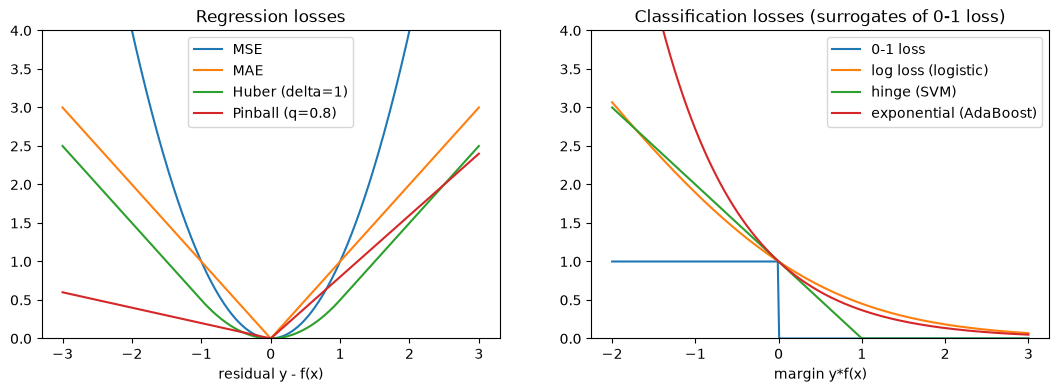

In [7]:
r = np.linspace(-3, 3, 300)
delta, tau = 1.0, 0.8
losses = {"MSE": r ** 2, "MAE": np.abs(r),
          "Huber (delta=1)": np.where(np.abs(r) <= delta, 0.5 * r ** 2, delta * (np.abs(r) - 0.5 * delta)),
          "Pinball (q=0.8)": np.where(r >= 0, tau * r, (tau - 1) * r)}
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for k_, v in losses.items():
    axes[0].plot(r, v, label=k_)
axes[0].set(xlabel="residual y - f(x)", ylim=(0, 4), title="Regression losses"); axes[0].legend()
m = np.linspace(-2, 3, 300)                         # margin y*f(x), y in {-1,+1}
axes[1].plot(m, (m < 0).astype(float), label="0-1 loss")
axes[1].plot(m, np.log2(1 + np.exp(-m)), label="log loss (logistic)")
axes[1].plot(m, np.maximum(0, 1 - m), label="hinge (SVM)")
axes[1].plot(m, np.exp(-m), label="exponential (AdaBoost)")
axes[1].set(xlabel="margin y*f(x)", ylim=(0, 4), title="Classification losses (surrogates of 0-1 loss)"); axes[1].legend()
plt.show()

# **Part 2: Going Deeper - How Certain Is the MLE?**

The curvature of the log-likelihood at its peak measures how precisely the data pin down $\theta$. The **Fisher information** $I(\theta) = -\mathbb{E}[\partial^2\ell/\partial\theta^2]$ gives the asymptotic standard error $SE(\hat\theta)\approx 1/\sqrt{I(\hat\theta)}$. This is how statsmodels computes the standard errors and p-values of regression coefficients.

In [8]:
# Bernoulli: I(p) = n / (p(1-p))  ->  SE = sqrt(p(1-p)/n)
p_hat = k / n
se_fisher = np.sqrt(p_hat * (1 - p_hat) / n)
# numerical: curvature of the log-likelihood at the MLE
h = 1e-4
ll = lambda p: k * np.log(p) + (n - k) * np.log(1 - p)
curv = (ll(p_hat + h) - 2 * ll(p_hat) + ll(p_hat - h)) / h ** 2
print(f"SE from Fisher formula: {se_fisher:.4f} | from numerical curvature: {1 / np.sqrt(-curv):.4f}")

# The same for logistic regression: compare with statsmodels
import statsmodels.api as sm
Xl = sm.add_constant(rng.normal(size=(300, 2)))
yl = (rng.random(300) < 1 / (1 + np.exp(-(Xl @ [0.3, 1.0, -0.8])))).astype(int)
fit = sm.Logit(yl, Xl).fit(disp=0)
p_ = fit.predict(Xl)
fisher = (Xl * (p_ * (1 - p_))[:, None]).T @ Xl
print("SE from inverse Fisher information:", np.sqrt(np.diag(np.linalg.inv(fisher))).round(4))
print("SE reported by statsmodels        :", fit.bse.round(4))

SE from Fisher formula: 0.0604 | from numerical curvature: 0.0604


SE from inverse Fisher information: [0.1348 0.1524 0.1526]
SE reported by statsmodels        : [0.1348 0.1524 0.1526]


### MLE can overfit
The MLE is not always good: for a Gaussian with **one** sample, $\hat\sigma = 0$ (infinite certainty); for perfectly separable classes, logistic-regression weights go to infinity. Priors/regularisation (MAP) and full Bayesian inference (Day 53) fix this.

## **Practice Problems**
1. Find the MLE of the rate $\lambda$ of a Poisson distribution from `rng.poisson(3.7, 100)` numerically and compare with the closed form $\bar x$.
2. Show numerically that minimising the pinball loss with $q=0.9$ over a constant $c$ gives the 90th percentile of the data.
3. In the Beta-prior example, what prior $(\alpha, \beta)$ makes MAP equal to MLE?
4. *(Advanced)* Fit the exponential distribution's rate by MLE for `rng.exponential(0.5, 400)` and give a Fisher-information 95% CI.

In [9]:
# Solution 1
cnt = rng.poisson(3.7, 100)
lam = optimize.minimize_scalar(lambda l: -stats.poisson.logpmf(cnt, l).sum(), bounds=(0.1, 10), method="bounded").x
print(f"Poisson MLE {lam:.4f} vs mean {cnt.mean():.4f}")
# Solution 2
d = rng.normal(size=1000)
c = optimize.minimize_scalar(lambda c: np.mean(np.where(d - c >= 0, 0.9 * (d - c), -0.1 * (d - c)))).x
print(f"pinball minimiser {c:.3f} vs 90th percentile {np.quantile(d, 0.9):.3f}")
# Solution 3
print("alpha = beta = 1 (uniform prior) -> MAP = MLE")
# Solution 4
e = rng.exponential(0.5, 400); lam_hat = 1 / e.mean(); se = lam_hat / np.sqrt(len(e))   # I(lambda) = n / lambda^2
print(f"rate = {lam_hat:.3f}, 95% CI [{lam_hat - 1.96 * se:.3f}, {lam_hat + 1.96 * se:.3f}] (true 2.0)")

Poisson MLE 3.9000 vs mean 3.9000
pinball minimiser 1.270 vs 90th percentile 1.270
alpha = beta = 1 (uniform prior) -> MAP = MLE
rate = 2.145, 95% CI [1.935, 2.355] (true 2.0)


## **Key References**
- Fisher, R. A. (1922). On the mathematical foundations of theoretical statistics. *Philosophical Transactions of the Royal Society A*, 222, 309-368.
- Bishop, C. M. (2006). *Pattern Recognition and Machine Learning*, Chapters 1-3. Springer.
- Murphy, K. P. (2022). *Probabilistic Machine Learning: An Introduction*, Chapter 4. MIT Press.
- Huber, P. J. (1964). Robust estimation of a location parameter. *The Annals of Mathematical Statistics*, 35(1), 73-101.
- Koenker, R., & Bassett, G. (1978). Regression quantiles. *Econometrica*, 46(1), 33-50.